# Handwritten Digit Recognition
## CodeAlpha Project - Task 3
---

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix
import seaborn as sns


## 2. Load Data

In [2]:
# Load MNIST data directly from keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Number of training images:", x_train.shape)
print("Number of testing images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of training images: (60000, 28, 28)
Number of testing images: (10000, 28, 28)


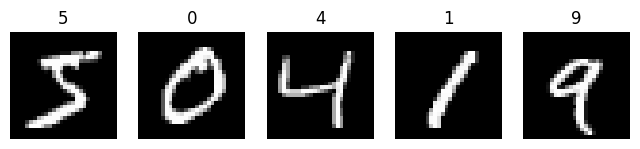

In [3]:
# Visualize some images
plt.figure(figsize=(8, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
plt.show()

## 3. Preprocessing

In [4]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add a fourth dimension (color channel) because CNN requires (28, 28, 1) shape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training data shape after preprocessing:", x_train.shape)

Training data shape after preprocessing: (60000, 28, 28, 1)


## 4. Build the Model (CNN)

In [5]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Dropout
    layers.Dropout(0.25),

    # Flatten
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Output layer: 10 units for digits 0-9
    layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 5. Model Training

In [7]:
# EarlyStopping
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
#Fit
history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 74s 84ms/step - accuracy: 0.9187 - loss: 0.2736 - val_accuracy: 0.9855 - val_loss: 0.0540
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 67s 80ms/step - accuracy: 0.9691 - loss: 0.1074 - val_accuracy: 0.9887 - val_loss: 0.0424
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 67s 79ms/step - accuracy: 0.9749 - loss: 0.0841 - val_accuracy: 0.9880 - val_loss: 0.0449
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 66s 78ms/step - accuracy: 0.9791 - loss: 0.0720 - val_accuracy: 0.9893 - val_loss: 0.0441
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 67s 80ms/step - accuracy: 0.9818 - loss: 0.0641 - val_accuracy: 0.9890 - val_loss: 0.0388
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 77ms/step - accuracy: 0.9828 - loss: 0.0577 - val_accuracy: 0.9897 - val_loss: 0.0408
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 78ms/step - accuracy: 0.9836 - loss: 0.0526 - val_accuracy: 0.9918 - val_loss: 0.0386
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 68s 80ms/step - accuracy: 0.9851 - loss: 0.0503 - 

## 6. Model Evaluation

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Model accuracy on test data:", round(test_acc * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9919 - loss: 0.0292
Model accuracy on test data: 99.19 %


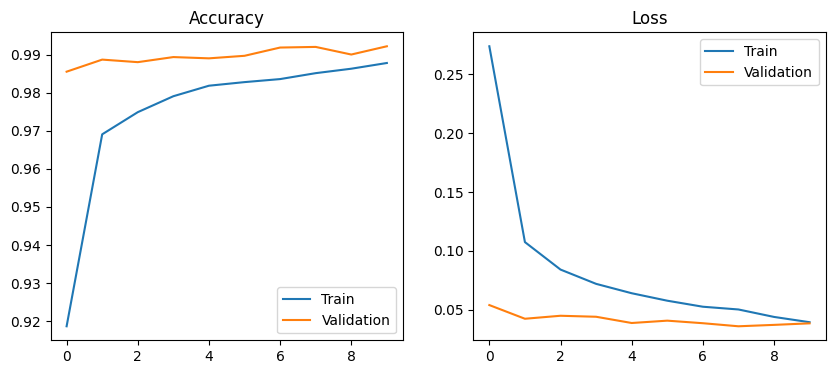

In [9]:
# Plot accuracy and loss curves over epochs
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


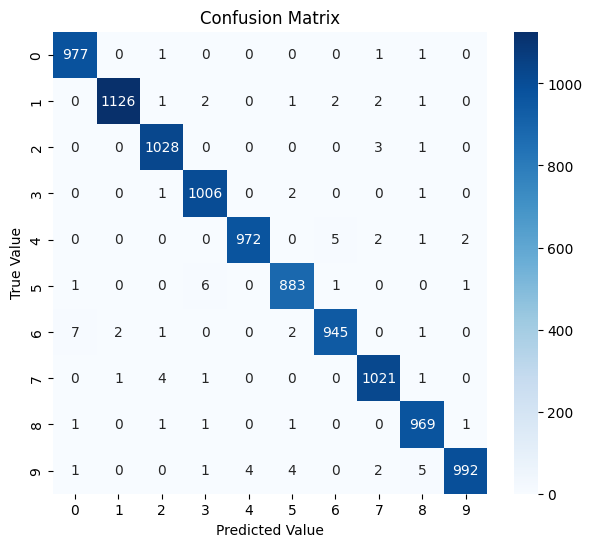

In [10]:
# Confusion Matrix to visualize where the model makes mistakes
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Value")
plt.ylabel("True Value")
plt.title("Confusion Matrix")
plt.show()

## 7. Save Model

In [11]:
model.save("handwritten_digit_model.keras")
print("Model saved successfully!")

Model saved successfully!


## END